In [ ]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO('/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/sub-231/ses-01/ieeg/sub-231_ses-01_run-EA6301CU.nwb' , 'r')
nwbfile = io.read()

In [ ]:
nwbfile


root pynwb.file.NWBFile at 0x139638044866512
Fields:
  acquisition: {
    ElectricalSeries_EKG <class 'pynwb.ecephys.ElectricalSeries'>,
    ElectricalSeries_misc <class 'pynwb.ecephys.ElectricalSeries'>,
    ElectricalSeries_sEEG <class 'pynwb.ecephys.ElectricalSeries'>,
    ElectricalSeries_scalp_EEG <class 'pynwb.ecephys.ElectricalSeries'>
  }
  devices: {
    NihonKohden <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    EKG <class 'pynwb.ecephys.ElectrodeGroup'>,
    misc <class 'pynwb.ecephys.ElectrodeGroup'>,
    sEEG <class 'pynwb.ecephys.ElectrodeGroup'>,
    scalp_EEG <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experimenter: ['Keller Lab']
  file_create_date: [datetime.datetime(2026, 1, 28, 10, 52, 57, 522452, tzinfo=tzoffset(None, -28800))]
  identifier: sub-256_ses-01
  institution: Stanford University
  lab: Precision Neurotherapeutics Lab
  session_description: iEEG recording from patient sub-256
  session_start_time: 2000-01-10 18:45:50-08:00
  subject: subject pynwb.file.Subject at 0x139637928351392
Fields:
  age__reference: birth
  description: Epilepsy patient with intracranial electrodes
  subject_id: sub-256

  timestamps_reference_time: 2000-01-10 18:45:50-08:00
  was_generated_by: <StrDataset for HDF5 dataset "was_generated_by": shape (1, 2), type "|O">

In [ ]:
seeg = nwbfile.acquisition["ElectricalSeries_sEEG"]


In [19]:
seeg     = nwbfile.acquisition["ElectricalSeries_sEEG"]
regions   = seeg.electrodes.data[:]
print("regions", regions)
labels   = nwbfile.electrodes["location"].data[:]
print("labels", labels)
electrode_name = "LTHA1"
chan_idx    = int(np.where(labels[region] == electrode_name)[0][0])
voltage_ds  = seeg.data[:, chan_idx][::downsample]
time_s      = np.arange(len(voltage_ds)) / (seeg.rate / downsample)

regions [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57
  58  59  60  61  62  63  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115
 116 117 118 119 120 121 122 123 124 125 126 127 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]
labels ['LTHA1' 'LTHA2' 'LTHA3' 'LTHA4' 'LTHA5' 'LTHA6' 'LTHA7' 'LTHA8' 'LTHA9'
 'LTHA10' 'LTHA13' 'LTHA14' 'LTHA15' 'LTHA16' 'RTHA1' 'RTHA2' 'RTHA3'
 'RTHA4' 'RTHA5' 'E' 'RTHA6' 'RTHA7' 'LTHA11' 'LTHA12' 'RTHA8' 'RTHA9'
 'RTHA10' 'RTHA11' 'RTHA12' 'RTHA13' 'RTHA14' 'RTHA15' 'RTHA16' 'LCM1'
 'LCM2' 'LCM3' 'LCM4' 'DC02' 'DC03' 'DC04' 'LCM5' 'LCM6' 'LCM7' 'LCM8'
 'LCM9' 'LCM10' 'LCM11' 'LCM12' 'LCM13' 'LCM14' 'LORB1' 'LORB2' 'LOR

IndexError: index 164 is out of bounds for axis 0 with size 164

In [50]:
import seaborn as sns
voltage_shorter = voltage_ds[:-200000]
time_s_shorter = time_s[:-200000]

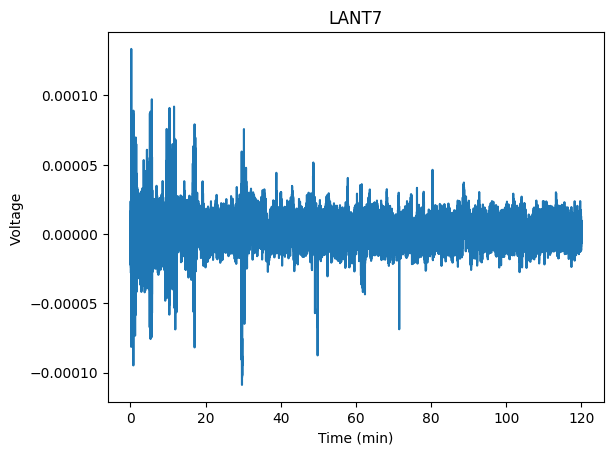

In [51]:
# plot
import matplotlib.pyplot as plt
sns.lineplot(x=time_s / 60, y=voltage_ds)
plt.xlabel("Time (min)")
plt.ylabel("Voltage ")
plt.title(electrode_name)
plt.show()

Run: 2000-01-10 20:45:50  →  2000-01-10 22:45:50  (2.00 hr)
                   date   time_hr  max_pain
123 2000-01-10 21:07:00  0.352778       0.0


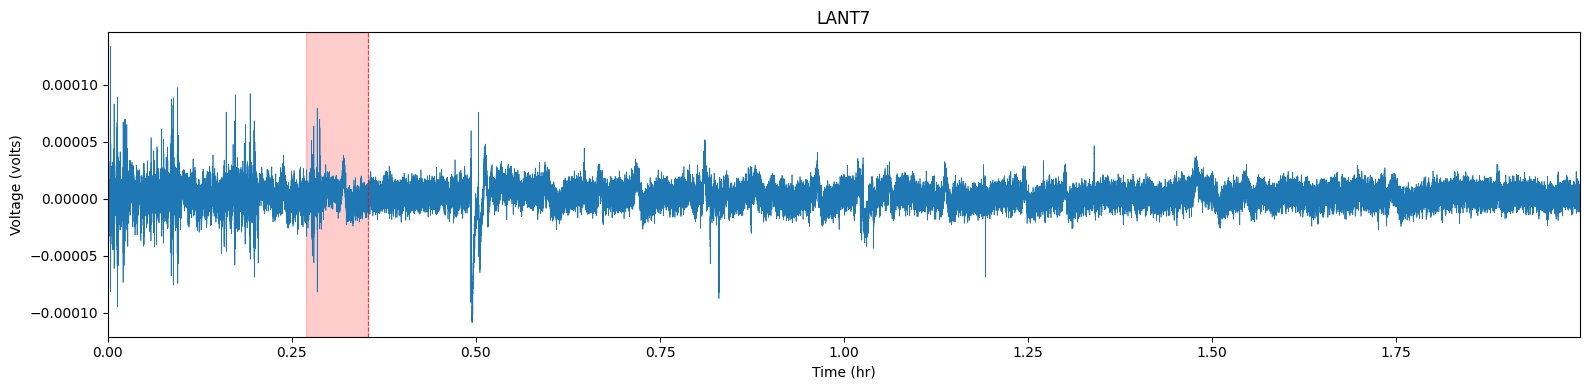

In [52]:
# PLOTS PAIN SCORES


# ── time anchor ───────────────────────────────────────────────────────────────
run_start = pd.Timestamp(nwbfile.session_start_time).tz_localize(None)
n_samples = seeg.data.shape[0]
run_end   = run_start + pd.Timedelta(seconds=n_samples / seeg.rate)

print(f"Run: {run_start}  →  {run_end}  ({n_samples / seeg.rate / 3600:.2f} hr)")

# ── filter pain scores to this run ───────────────────────────────────────────
pain_in_run = pain_df[pain_df["date"].between(run_start, run_end)].copy()
pain_in_run["time_hr"] = (pain_in_run["date"] - run_start).dt.total_seconds() / 3600

print(pain_in_run[["date", "time_hr", "max_pain"]])

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

time_hr = np.arange(len(voltage_ds)) / (seeg.rate / downsample) / 3600
sns.lineplot(x=time_hr, y=voltage_ds, linewidth=0.5, ax=ax)

# shade 5-minute window prior to each pain score
for _, row in pain_in_run.iterrows():
    ax.axvspan(row["time_hr"] - 5/60, row["time_hr"], alpha=0.2, color="red", label=f'pain={row["max_pain"]:.0f}')
    ax.axvline(row["time_hr"], color="red", lw=0.8, ls="--", alpha=0.7)

ax.set_xlabel("Time (hr)")
ax.set_ylabel(f"Voltage ({seeg.unit})")
ax.set_title(electrode_name)
ax.set_xlim(0, time_hr[-1])
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.ticker as mticker



# ── config ────────────────────────────────────────────────────────────────────
SUB            = "sub-256"
SES            = "ses-01"
electrode_name = "LANT7"
downsample     = 10
N_RUNS         = 3
FIRST_RUN      = "sub-256_ses-01_run-IA61943H.nwb"  # first run filename

ieeg_base = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ieeg"
ehr_base  = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ehr"

# ── load EHR ──────────────────────────────────────────────────────────────────
pain_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_pain-scores.csv",
                      parse_dates=["date", "session_start", "session_end"])
meds_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_med-admin.csv",
                      parse_dates=["taken_date", "session_start", "session_end"])

# ── find N consecutive runs alphabetically starting from FIRST_RUN ────────────
all_files   = sorted(glob.glob(f"{ieeg_base}/*.nwb"))
first_names = [os.path.basename(f) for f in all_files]
start_idx   = first_names.index(FIRST_RUN)
nwb_files   = all_files[start_idx : start_idx + N_RUNS]
print(f"Using runs:")
for f in nwb_files:
    print(f"  {os.path.basename(f)}")

# ── load each run ─────────────────────────────────────────────────────────────
segments = []

for path in nwb_files:
    io      = NWBHDF5IO(path, "r")
    nwb     = io.read()
    seeg    = nwb.acquisition["ElectricalSeries_sEEG"]
    labels  = nwb.electrodes["location"].data[:]
    region  = seeg.electrodes.data[:]

    chan_idx   = int(np.where(labels[region] == electrode_name)[0][0])
    voltage_ds = seeg.data[:, chan_idx][::downsample]
    run_start  = pd.Timestamp(nwb.session_start_time).tz_localize(None)
    run_end    = run_start + pd.Timedelta(seconds=seeg.data.shape[0] / seeg.rate)

    segments.append({
        "voltage":   voltage_ds,
        "run_start": run_start,
        "run_end":   run_end,
        "fs_ds":     seeg.rate / downsample,
        "unit":      seeg.unit,
        "io":        io,
    })
    print(f"  Loaded {os.path.basename(path)}  ({seeg.data.shape[0] / seeg.rate / 3600:.2f} hr)")

# ── build continuous time axis ────────────────────────────────────────────────
t0 = segments[0]["run_start"]
for seg in segments:
    offset_hr    = (seg["run_start"] - t0).total_seconds() / 3600
    seg["time_hr"] = np.arange(len(seg["voltage"])) / seg["fs_ds"] / 3600 + offset_hr

# ── filter EHR to full span ───────────────────────────────────────────────────
span_start = segments[0]["run_start"]
span_end   = segments[-1]["run_end"]

pain_in_span = pain_df[pain_df["date"].between(span_start, span_end)].copy()
pain_in_span["time_hr"] = (pain_in_span["date"] - t0).dt.total_seconds() / 3600

meds_in_span = meds_df[meds_df["taken_date"].between(span_start, span_end)].copy()
meds_in_span["time_hr"] = (meds_in_span["taken_date"] - t0).dt.total_seconds() / 3600

print(f"\nPain scores in span: {len(pain_in_span)}")
print(f"Med admins in span:  {len(meds_in_span)}")

Using runs:
  sub-256_ses-01_run-IA61943H.nwb
  sub-256_ses-01_run-IA61943I.nwb
  sub-256_ses-01_run-IA61943J.nwb
  Loaded sub-256_ses-01_run-IA61943H.nwb  (2.00 hr)
  Loaded sub-256_ses-01_run-IA61943I.nwb  (2.00 hr)
  Loaded sub-256_ses-01_run-IA61943J.nwb  (2.00 hr)

Pain scores in span: 4
Med admins in span:  8


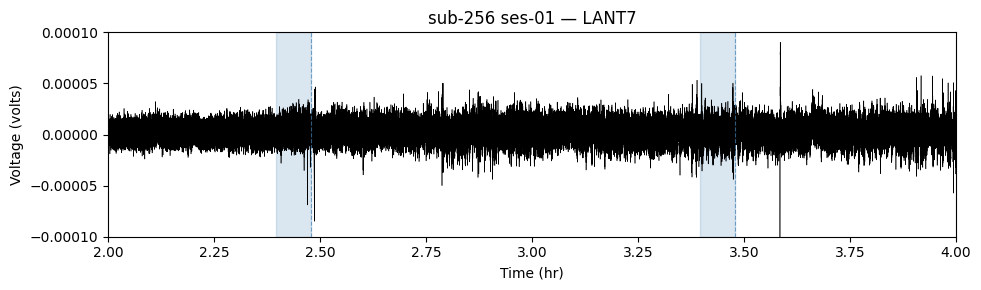

In [11]:
import seaborn as sns 

plot_segs = segments

fig, ax = plt.subplots(figsize=(10, 3))

for seg in plot_segs:
    sns.lineplot(x=seg["time_hr"], y=seg["voltage"],
                 linewidth=0.4, color="black", ax=ax)

for _, row in pain_in_span.iterrows():
    ax.axvspan(row["time_hr"] - 5/60, row["time_hr"], alpha=0.2, color="steelblue")
    ax.axvline(row["time_hr"], color="steelblue", lw=0.8, ls="--", alpha=0.7)



ax.set_xlabel("Time (hr)")
ax.set_ylabel(f"Voltage ({segments[0]['unit']})")
ax.set_title(f"{SUB} {SES} — {electrode_name}")
ax.set_xlim(2, 4)
ax.set_xlabel("Time (hr)")
ax.set_ylim(-.0001, .0001)
plt.tight_layout()
plt.savefig("plots/ieeg_with_pain_epochs_overlayed_sub256_ses1.svg")

In [ ]:
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.ticker as mticker

segments = []

# ── config ────────────────────────────────────────────────────────────────────
SUB             = "sub-256"
SES             = "ses-01"
electrode_names = ["LANT7", "LANT8"]
downsample      = 10
N_RUNS          = 3
FIRST_RUN       = "sub-256_ses-01_run-IA61943H.nwb"

ieeg_base = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ieeg"
ehr_base  = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ehr"

# ── load EHR ──────────────────────────────────────────────────────────────────
pain_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_pain-scores.csv",
                      parse_dates=["date", "session_start", "session_end"])
meds_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_med-admin.csv",
                      parse_dates=["taken_date", "session_start", "session_end"])

# ── find N consecutive runs alphabetically starting from FIRST_RUN ────────────
all_files  = sorted(glob.glob(f"{ieeg_base}/*.nwb"))
first_names = [os.path.basename(f) for f in all_files]
start_idx  = first_names.index(FIRST_RUN)
nwb_files  = all_files[start_idx : start_idx + N_RUNS]
print("Using runs:")
for f in nwb_files:
    print(f"  {os.path.basename(f)}")

# ── load each run ─────────────────────────────────────────────────────────────
for path in nwb_files:
    io        = NWBHDF5IO(path, "r")
    nwb       = io.read()
    seeg      = nwb.acquisition["ElectricalSeries_sEEG"]
    labels    = nwb.electrodes["location"].data[:]
    region    = seeg.electrodes.data[:]
    run_start = pd.Timestamp(nwb.session_start_time).tz_localize(None)
    run_end   = run_start + pd.Timedelta(seconds=seeg.data.shape[0] / seeg.rate)

    voltages = {}
    for name in electrode_names:
        chan_idx = int(np.where(labels[region] == name)[0][0])
        voltages[name] = seeg.data[:, chan_idx][::downsample]

    segments.append({
        "voltage":   voltages,
        "run_start": run_start,
        "run_end":   run_end,
        "fs_ds":     seeg.rate / downsample,
        "unit":      seeg.unit,
        "io":        io,
    })
    print(f"  Loaded {os.path.basename(path)}  ({seeg.data.shape[0] / seeg.rate / 3600:.2f} hr)")

# ── build continuous time axis ────────────────────────────────────────────────
t0 = segments[0]["run_start"]
for seg in segments:
    offset_hr      = (seg["run_start"] - t0).total_seconds() / 3600
    n_samples      = len(next(iter(seg["voltage"].values())))
    seg["time_hr"] = np.arange(n_samples) / seg["fs_ds"] / 3600 + offset_hr

# ── filter EHR to full span ───────────────────────────────────────────────────
span_start = segments[0]["run_start"]
span_end   = segments[-1]["run_end"]

pain_in_span = pain_df[pain_df["date"].between(span_start, span_end)].copy()
pain_in_span["time_hr"] = (pain_in_span["date"] - t0).dt.total_seconds() / 3600

meds_in_span = meds_df[meds_df["taken_date"].between(span_start, span_end)].copy()
meds_in_span["time_hr"] = (meds_in_span["taken_date"] - t0).dt.total_seconds() / 3600

print(f"\nPain scores in span: {len(pain_in_span)}")
print(f"Med admins in span:  {len(meds_in_span)}")

Using runs:
  sub-256_ses-01_run-IA61943H.nwb
  sub-256_ses-01_run-IA61943I.nwb
  sub-256_ses-01_run-IA61943J.nwb


NameError: name 'voltage_ds' is not defined

In [1]:
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.ticker as mticker

segments = []

# ── config ────────────────────────────────────────────────────────────────────
SUB             = "sub-256"
SES             = "ses-01"
electrode_names = ["LANT7", "LANT8"]
downsample      = 10
N_RUNS          = 3
FIRST_RUN       = "sub-256_ses-01_run-IA61943H.nwb"

ieeg_base = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ieeg"
ehr_base  = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ehr"

# ── load EHR ──────────────────────────────────────────────────────────────────
pain_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_pain-scores.csv",
                      parse_dates=["date", "session_start", "session_end"])
meds_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_med-admin.csv",
                      parse_dates=["taken_date", "session_start", "session_end"])

# ── find N consecutive runs alphabetically starting from FIRST_RUN ────────────
all_files  = sorted(glob.glob(f"{ieeg_base}/*.nwb"))
first_names = [os.path.basename(f) for f in all_files]
start_idx  = first_names.index(FIRST_RUN)
nwb_files  = all_files[start_idx : start_idx + N_RUNS]
print("Using runs:")
for f in nwb_files:
    print(f"  {os.path.basename(f)}")

# ── load each run ─────────────────────────────────────────────────────────────
for path in nwb_files:
    io        = NWBHDF5IO(path, "r")
    nwb       = io.read()
    seeg      = nwb.acquisition["ElectricalSeries_sEEG"]
    labels    = nwb.electrodes["location"].data[:]
    region    = seeg.electrodes.data[:]
    run_start = pd.Timestamp(nwb.session_start_time).tz_localize(None)
    run_end   = run_start + pd.Timedelta(seconds=seeg.data.shape[0] / seeg.rate)

    voltages = {}
    for name in electrode_names:
        chan_idx = int(np.where(labels[region] == name)[0][0])
        voltages[name] = seeg.data[:, chan_idx][::downsample]

    segments.append({
        "voltage":   voltages,
        "run_start": run_start,
        "run_end":   run_end,
        "fs_ds":     seeg.rate / downsample,
        "unit":      seeg.unit,
        "io":        io,
    })
    print(f"  Loaded {os.path.basename(path)}  ({seeg.data.shape[0] / seeg.rate / 3600:.2f} hr)")

# ── build continuous time axis ────────────────────────────────────────────────
t0 = segments[0]["run_start"]
for seg in segments:
    offset_hr      = (seg["run_start"] - t0).total_seconds() / 3600
    n_samples      = len(next(iter(seg["voltage"].values())))
    seg["time_hr"] = np.arange(n_samples) / seg["fs_ds"] / 3600 + offset_hr

# ── filter EHR to full span ───────────────────────────────────────────────────
span_start = segments[0]["run_start"]
span_end   = segments[-1]["run_end"]

pain_in_span = pain_df[pain_df["date"].between(span_start, span_end)].copy()
pain_in_span["time_hr"] = (pain_in_span["date"] - t0).dt.total_seconds() / 3600

meds_in_span = meds_df[meds_df["taken_date"].between(span_start, span_end)].copy()
meds_in_span["time_hr"] = (meds_in_span["taken_date"] - t0).dt.total_seconds() / 3600

print(f"\nPain scores in span: {len(pain_in_span)}")
print(f"Med admins in span:  {len(meds_in_span)}")

Using runs:
  sub-256_ses-01_run-IA61943H.nwb
  sub-256_ses-01_run-IA61943I.nwb
  sub-256_ses-01_run-IA61943J.nwb
  Loaded sub-256_ses-01_run-IA61943H.nwb  (2.00 hr)
  Loaded sub-256_ses-01_run-IA61943I.nwb  (2.00 hr)
  Loaded sub-256_ses-01_run-IA61943J.nwb  (2.00 hr)

Pain scores in span: 4
Med admins in span:  8


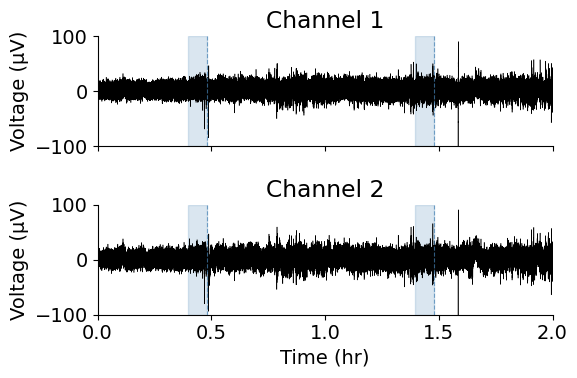

In [69]:
import seaborn as sns

plot_segs = segments
t_offset  = 2  # hours to subtract so display starts at 0

fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True, sharey=True)

for ax, name, ch in zip(axes, ["LANT7", "LANT8"], ["Channel 1", "Channel 2"]):
    for seg in plot_segs:
        sns.lineplot(x=seg["time_hr"] - t_offset, y=seg["voltage"][name] * 1e6,
                     linewidth=0.4, color="black", ax=ax)

    for _, row in pain_in_span.iterrows():
        ax.axvspan(row["time_hr"] - t_offset - 5/60, row["time_hr"] - t_offset,
                   alpha=0.2, color="steelblue")
        ax.axvline(row["time_hr"] - t_offset, color="steelblue", lw=0.8, ls="--", alpha=0.7)

    ax.set_ylabel("Voltage (µV)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_xlim(0, 2)
axes[0].set_ylim(-100, 100)
axes[0].set_title("Channel 1")
axes[1].set_title("Channel 2")
axes[1].set_xlabel("Time (hr)", fontsize=14)

plt.tight_layout()
plt.savefig("plots/ieeg_with_pain_epochs_overlayed_sub256_ses1.svg")

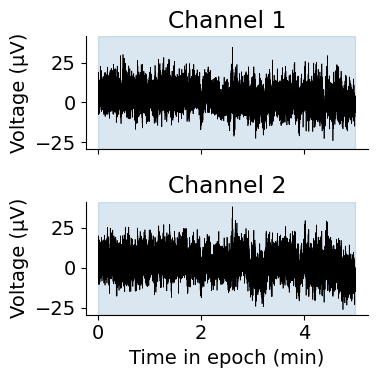

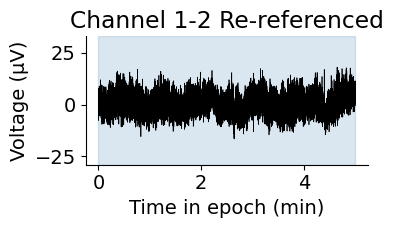

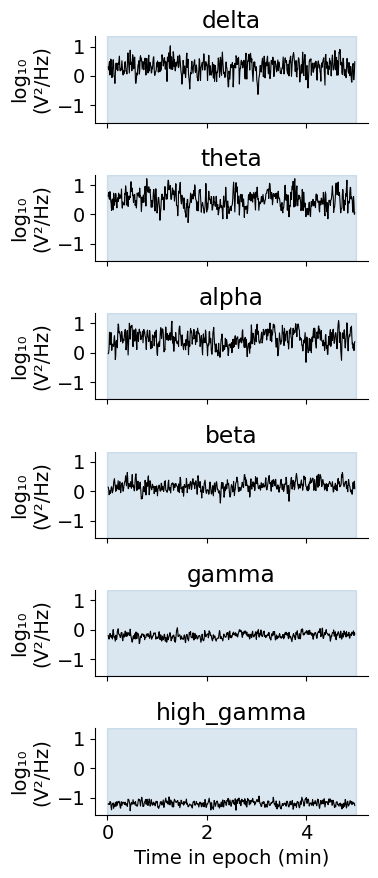

In [74]:
plt.rcParams.update({"font.size": 14}) 
# ── sliding window bandpower ──────────────────────────────────────────────────
WIN_SEC  = 2.0
STEP_SEC = 0.5
win_samp  = int(WIN_SEC * fs)
step_samp = int(STEP_SEC * fs)

n_samples = len(sig_bip)
starts    = np.arange(0, n_samples - win_samp + 1, step_samp)

band_names = list(BANDS.keys())
bp_matrix  = np.zeros((len(band_names), len(starts)))

for i, s in enumerate(starts):
    window = sig_bip[s : s + win_samp]
    freqs_w, psd_w = welch(window, fs=fs, nperseg=min(win_samp, len(window)))
    for j, (name, (lo, hi)) in enumerate(BANDS.items()):
        bp_matrix[j, i] = bandpower(freqs_w, psd_w, lo, hi)

t_windows = (starts + win_samp / 2) / fs / 60

SCALE = 1e6  # V → µV

# sig_lant7 = sig_lant7 * SCALE
# sig_lant8 = sig_lant8 * SCALE
# sig_bip   = sig_bip   * SCALE

# ── figure 1: raw voltage traces ─────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 1, figsize=(4, 4), sharex=True, sharey=True)

for ax, sig, name in zip(axes1, [sig_lant7, sig_lant8], ["LANT7", "LANT8"]):
    ax.axvspan(0, 5, alpha=0.2, color="steelblue")
    ax.plot(t_plot, sig, color="black", lw=0.5)
    ax.set_ylabel("Voltage (µV)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes1[1].set_xlabel("Time in epoch (min)")
axes1[1].set_title("Channel 2")
axes1[0].set_title("Channel 1")

plt.tight_layout()
plt.savefig("plots/pain_epoch_raw_signals_sub256_ses1.svg")
plt.show()

# ── figure 2: bipolar re-referenced ──────────────────────────────────────────
fig2, ax2 = plt.subplots(1, 1, figsize=(4, 2.5))
ax2.axvspan(0, 5, alpha=0.2, color="steelblue")

ax2.plot(t_plot, sig_bip, lw=0.5, color="black")
ax2.set_ylabel("Voltage (µV)")
ax2.set_xlabel("Time in epoch (min)")
ax2.set_ylim(-29,33)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_title("Channel 1-2 Re-referenced")

plt.tight_layout()
plt.savefig("plots/pain_epoch_bipolar_sub256_ses1.svg")
plt.show()


fig3, axes3 = plt.subplots(len(band_names), 1, figsize=(4, 9), sharex=True, sharey=True)

for ax, name, bp_row in zip(axes3, band_names, bp_matrix):
    ax.axvspan(0, 5, alpha=0.2, color="steelblue")
    ax.plot(t_windows, np.log10(bp_row), color="black", lw=0.8)
    ax.set_ylabel("log₁₀\n(V²/Hz)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(name)

axes3[-1].set_xlabel("Time in epoch (min)")

plt.tight_layout()
plt.savefig("plots/pain_epoch_bandpower_sub256_ses1.svg")
plt.show()

In [7]:
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
import glob
import os

# ── config ────────────────────────────────────────────────────────────────────
SUB            = "sub-256"
SES            = "ses-01"
electrode_name = "LANT7"
downsample     = 100
N_RUNS         = 3
FIRST_RUN      = "sub-256_ses-01_run-IA61943A.nwb"

ieeg_base = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ieeg"
ehr_base  = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ehr"

# ── load EHR ──────────────────────────────────────────────────────────────────
pain_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_pain-scores.csv",
                      parse_dates=["date", "session_start", "session_end"])
meds_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_med-admin.csv",
                      parse_dates=["taken_date", "session_start", "session_end"])

# ── find N consecutive runs alphabetically starting from FIRST_RUN ────────────
all_files  = sorted(glob.glob(f"{ieeg_base}/*.nwb"))
start_idx  = [os.path.basename(f) for f in all_files].index(FIRST_RUN)
nwb_files  = all_files[start_idx : start_idx + N_RUNS]
print("Using runs:")
for f in nwb_files:
    print(f"  {os.path.basename(f)}")

# ── load each run ─────────────────────────────────────────────────────────────
segments = []

for path in nwb_files:
    io     = NWBHDF5IO(path, "r")
    nwb    = io.read()
    seeg   = nwb.acquisition["ElectricalSeries_sEEG"]
    labels = nwb.electrodes["location"].data[:]
    region = seeg.electrodes.data[:]

    chan_idx  = int(np.where(labels[region] == electrode_name)[0][0])
    # adjacent contact is the next index in the region
    chan_idx2 = chan_idx + 1
    label2    = labels[region][chan_idx2]

    voltage_ds  = seeg.data[:, chan_idx][::downsample]
    voltage_ds2 = seeg.data[:, chan_idx2][::downsample]

    run_start = pd.Timestamp(nwb.session_start_time).tz_localize(None)
    run_end   = run_start + pd.Timedelta(seconds=seeg.data.shape[0] / seeg.rate)

    segments.append({
        "voltage":   voltage_ds,
        "voltage2":  voltage_ds2,
        "label2":    label2,
        "run_start": run_start,
        "run_end":   run_end,
        "fs_ds":     seeg.rate / downsample,
        "unit":      seeg.unit,
        "io":        io,
    })
    print(f"  Loaded {os.path.basename(path)}  — channels: {electrode_name}, {label2}")

# ── build continuous time axis ────────────────────────────────────────────────
t0 = segments[0]["run_start"]
for seg in segments:
    offset_hr      = (seg["run_start"] - t0).total_seconds() / 3600
    seg["time_hr"] = np.arange(len(seg["voltage"])) / seg["fs_ds"] / 3600 + offset_hr

# ── filter EHR to full span ───────────────────────────────────────────────────
span_start = segments[0]["run_start"]
span_end   = segments[-1]["run_end"]

pain_in_span = pain_df[pain_df["date"].between(span_start, span_end)].copy()
pain_in_span["time_hr"] = (pain_in_span["date"] - t0).dt.total_seconds() / 3600

meds_in_span = meds_df[meds_df["taken_date"].between(span_start, span_end)].copy()
meds_in_span["time_hr"] = (meds_in_span["taken_date"] - t0).dt.total_seconds() / 3600

print(f"\nPain scores in span: {len(pain_in_span)}")
print(f"Med admins in span:  {len(meds_in_span)}")

Using runs:
  sub-256_ses-01_run-IA61943A.nwb
  sub-256_ses-01_run-IA61943B.nwb
  sub-256_ses-01_run-IA61943C.nwb
  Loaded sub-256_ses-01_run-IA61943A.nwb  — channels: LANT7, LANT8
  Loaded sub-256_ses-01_run-IA61943B.nwb  — channels: LANT7, LANT8
  Loaded sub-256_ses-01_run-IA61943C.nwb  — channels: LANT7, LANT8

Pain scores in span: 2
Med admins in span:  6


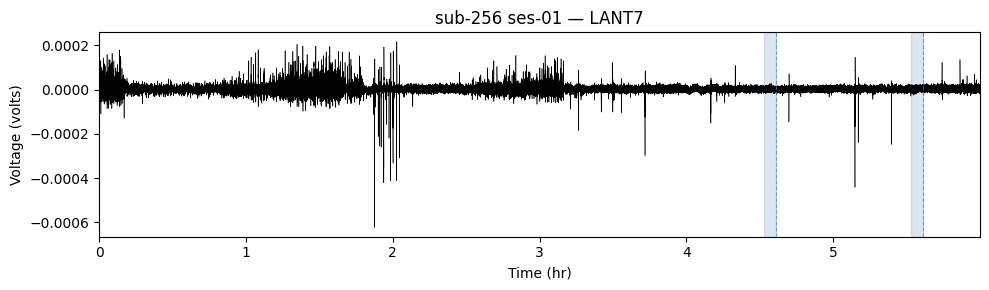

In [ ]:
plot_segs = segments[:3]

fig, ax = plt.subplots(figsize=(10, 3))

for seg in plot_segs:
    sns.lineplot(x=seg["time_hr"], y=seg["voltage"],
                 linewidth=0.4, color="black", ax=ax)

for _, row in pain_in_span.iterrows():
    ax.axvspan(row["time_hr"] - 5/60, row["time_hr"], alpha=0.2, color="steelblue")
    ax.axvline(row["time_hr"], color="steelblue", lw=0.8, ls="--", alpha=0.7)



ax.set_xlabel("Time (hr)")
ax.set_ylabel(f"Voltage ({segments[0]['unit']})")
ax.set_title(f"{SUB} {SES} — {electrode_name}")
ax.set_xlim(plot_segs[0]["time_hr"][0], plot_segs[-1]["time_hr"][-1])
plt.tight_layout()
ax.set_xlim(plot_segs[0]["time_hr"][0])

plt.savefig("plots/ieeg_with_pain_epochs_overlayed_sub256_ses1.svg")

In [ ]:
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
import glob
import os

# ── config ────────────────────────────────────────────────────────────────────
SUB            = "sub-256"
SES            = "ses-01"
electrode_name = "LANT7"
downsample     = 10
N_RUNS         = 3
FIRST_RUN      = "sub-256_ses-01_run-IA61946B.nwb"

ieeg_base = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ieeg"
ehr_base  = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ehr"

# ── load EHR ──────────────────────────────────────────────────────────────────
pain_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_pain-scores.csv",
                      parse_dates=["date", "session_start", "session_end"])
meds_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_med-admin.csv",
                      parse_dates=["taken_date", "session_start", "session_end"])

# ── find N consecutive runs alphabetically starting from FIRST_RUN ────────────
all_files  = sorted(glob.glob(f"{ieeg_base}/*.nwb"))
start_idx  = [os.path.basename(f) for f in all_files].index(FIRST_RUN)
nwb_files  = all_files[start_idx : start_idx + N_RUNS]
print("Using runs:")
for f in nwb_files:
    print(f"  {os.path.basename(f)}")

# ── load each run ─────────────────────────────────────────────────────────────
segments = []

for path in nwb_files:
    io     = NWBHDF5IO(path, "r")
    nwb    = io.read()
    seeg   = nwb.acquisition["ElectricalSeries_sEEG"]
    labels = nwb.electrodes["location"].data[:]
    region = seeg.electrodes.data[:]

    chan_idx  = int(np.where(labels[region] == electrode_name)[0][0])
    # adjacent contact is the next index in the region
    chan_idx2 = chan_idx + 1
    label2    = labels[region][chan_idx2]

    voltage_ds  = seeg.data[:, chan_idx][::downsample]
    voltage_ds2 = seeg.data[:, chan_idx2][::downsample]

    run_start = pd.Timestamp(nwb.session_start_time).tz_localize(None)
    run_end   = run_start + pd.Timedelta(seconds=seeg.data.shape[0] / seeg.rate)

    segments.append({
        "voltage":   voltage_ds,
        "voltage2":  voltage_ds2,
        "label2":    label2,
        "run_start": run_start,
        "run_end":   run_end,
        "fs_ds":     seeg.rate / downsample,
        "unit":      seeg.unit,
        "io":        io,
    })
    print(f"  Loaded {os.path.basename(path)}  — channels: {electrode_name}, {label2}")

# ── build continuous time axis ────────────────────────────────────────────────
t0 = segments[0]["run_start"]
for seg in segments:
    offset_hr      = (seg["run_start"] - t0).total_seconds() / 3600
    seg["time_hr"] = np.arange(len(seg["voltage"])) / seg["fs_ds"] / 3600 + offset_hr

# ── filter EHR to full span ───────────────────────────────────────────────────
span_start = segments[0]["run_start"]
span_end   = segments[-1]["run_end"]

pain_in_span = pain_df[pain_df["date"].between(span_start, span_end)].copy()
pain_in_span["time_hr"] = (pain_in_span["date"] - t0).dt.total_seconds() / 3600

meds_in_span = meds_df[meds_df["taken_date"].between(span_start, span_end)].copy()
meds_in_span["time_hr"] = (meds_in_span["taken_date"] - t0).dt.total_seconds() / 3600

print(f"\nPain scores in span: {len(pain_in_span)}")
print(f"Med admins in span:  {len(meds_in_span)}")

plot_segs = segments[:2]

fig, ax = plt.subplots(figsize=(10, 3))

for seg in plot_segs:
    sns.lineplot(x=seg["time_hr"], y=seg["voltage"] * 1000,
                 linewidth=0.4, color="black", ax=ax)

for _, row in pain_in_span.iterrows():
    ax.axvspan(row["time_hr"] - 5/60, row["time_hr"], alpha=0.2, color="steelblue")
    ax.axvline(row["time_hr"], color="steelblue", lw=0.8, ls="--", alpha=0.7)

ax.set_xlabel("Time (hr)")
ax.set_ylabel("Voltage (mV)")
ax.set_title(f"{SUB} {SES} — {electrode_name}")
ax.set_xlim(plot_segs[0]["time_hr"][0], 3)
plt.tight_layout()

plt.savefig("plots/ieeg_with_pain_epochs_overlayed_sub256_ses1.svg")

In [8]:
# ── load CSVs ─────────────────────────────────────────────────────────────────
ehr_base = f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/{SUB}/{SES}/ehr"

pain_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_pain-scores.csv",
                      parse_dates=["date", "session_start", "session_end"])
meds_df = pd.read_csv(f"{ehr_base}/{SUB}_{SES}_med-admin.csv",
                      parse_dates=["taken_date", "session_start", "session_end"])

# ── time anchor ───────────────────────────────────────────────────────────────
run_start = pd.Timestamp(nwbfile.session_start_time).tz_localize(None)
n_samples = seeg.data.shape[0]
run_end   = run_start + pd.Timedelta(seconds=n_samples / seeg.rate)

print(f"Run: {run_start}  →  {run_end}  ({n_samples / seeg.rate / 3600:.2f} hr)")

# ── filter to this run ────────────────────────────────────────────────────────
pain_in_run = pain_df[pain_df["date"].between(run_start, run_end)].copy()
pain_in_run["time_hr"] = (pain_in_run["date"] - run_start).dt.total_seconds() / 3600

meds_in_run = meds_df[meds_df["taken_date"].between(run_start, run_end)].copy()
meds_in_run["time_hr"] = (meds_in_run["taken_date"] - run_start).dt.total_seconds() / 3600

print(f"Pain scores in run: {len(pain_in_run)}")
print(f"Med admins in run:  {len(meds_in_run)}")
print(meds_in_run[["time_hr", "medication", "sig", "dose_unit", "route"]])

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

time_hr = np.arange(len(voltage_ds)) / (seeg.rate / downsample) / 3600
sns.lineplot(x=time_hr, y=voltage_ds, linewidth=0.5, ax=ax, color="steelblue")

# shade 5-min window prior to each pain score
for _, row in pain_in_run.iterrows():
    ax.axvspan(row["time_hr"] - 5/60, row["time_hr"],
               alpha=0.2, color="red")
    ax.axvline(row["time_hr"], color="red", lw=0.8, ls="--", alpha=0.7,
               label=f'pain={row["max_pain"]:.0f}')

# # vertical line per med admin, colored by route

# route_colors = {"Oral": "green", "Intravenous": "purple"}
# labeled_routes = set()
# for _, row in meds_in_run.iterrows():
#     route  = row["route"]
#     color  = route_colors.get(route, "orange")
#     label  = route if route not in labeled_routes else None
#     ax.axvline(row["time_hr"], color=color, lw=1.0, alpha=0.8, label=label)
#     labeled_routes.add(route)

ax.set_xlabel("Time (hr)")
ax.set_ylabel(f"Voltage ({seeg.unit})")
ax.set_title(electrode_name)
ax.set_xlim(0, time_hr[-1])
ax.legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

NameError: name 'nwbfile' is not defined

In [22]:
# ── Cell 1: imports ──────────────────────────────────────────────────────────
import glob
import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO

%matplotlib inline

In [23]:
# ── Cell 2: config ───────────────────────────────────────────────────────────
SUB       = "sub-256"
SES       = "ses-01"
N_RUNS    = 3          # number of consecutive runs to load
START_RUN = 4          # 0-based index into session-time-sorted run list

# Contact selection — set CONTACT_MODE to "shaft" or "manual"
#   shaft  → set SHAFT_NAME and SHAFT_CONTACT_N (picks contact N and N+1)
#   manual → set CHANNEL_INDICES to exactly two ints
CONTACT_MODE    = "shaft"
SHAFT_NAME      = "LACH"
SHAFT_CONTACT_N = 10        # 0-based within the shaft

DOWNSAMPLE_HZ = 100
OUTPUT_PNG    = f"{SUB}_{SES}_two_contacts.png"

DATA_ROOT = (
    f"/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB"
    f"/{SUB}/{SES}/ieeg"
)

In [24]:
# ── Cell 3: load data (run once) ─────────────────────────────────────────────

def get_session_start(path):
    with NWBHDF5IO(path, "r") as io:
        t = io.read().session_start_time
    return pd.Timestamp(t)

def resolve_channels(nwb_path):
    """Return (channel_indices, channel_labels) for the two contacts."""
    with NWBHDF5IO(nwb_path, "r") as io:
        nwb     = io.read()
        elec_df = nwb.electrodes.to_dataframe()
        seeg    = nwb.acquisition["ElectricalSeries_sEEG"]
        region  = seeg.electrodes.data[:]

    if CONTACT_MODE == "manual":
        idx    = list(CHANNEL_INDICES)
        labels = [str(elec_df.iloc[region[i]].get("label", f"ch{i}")) for i in idx]
        return idx, labels

    used_elec = elec_df.iloc[region].copy()
    used_elec["_chan_idx"] = range(len(used_elec))
    label_col = next(
        (c for c in ("label", "location", "group_name", "channel_name") if c in used_elec.columns),
        None
    )
    if label_col is None:
        raise ValueError(
            "No label column found in electrode table. "
            "Switch to CONTACT_MODE='manual' and set CHANNEL_INDICES."
        )
    shaft_rows = (
        used_elec[used_elec[label_col].str.upper().str.startswith(SHAFT_NAME.upper())]
        .sort_values("_chan_idx")
    )
    if len(shaft_rows) < SHAFT_CONTACT_N + 2:
        raise ValueError(
            f"Shaft '{SHAFT_NAME}' has {len(shaft_rows)} contact(s); "
            f"need at least {SHAFT_CONTACT_N + 2}."
        )
    row_a  = shaft_rows.iloc[SHAFT_CONTACT_N]
    row_b  = shaft_rows.iloc[SHAFT_CONTACT_N + 1]
    return [int(row_a["_chan_idx"]), int(row_b["_chan_idx"])], \
           [str(row_a[label_col]), str(row_b[label_col])]

def load_run(path, chan_idx):
    with NWBHDF5IO(path, "r") as io:
        nwb  = io.read()
        seeg = nwb.acquisition["ElectricalSeries_sEEG"]
        fs   = float(seeg.rate)
        t0   = pd.Timestamp(nwb.session_start_time)
        data = seeg.data[:, chan_idx]   # only the two channels — avoids loading ~12 GiB
    return data, fs, t0

# --- find & sort runs ---
all_files    = sorted(glob.glob(os.path.join(DATA_ROOT, "*.nwb")))
assert all_files, f"No NWB files found in {DATA_ROOT}"
print(f"Found {len(all_files)} run(s). Sorting by session start time …")

sorted_files = sorted(all_files, key=get_session_start)
assert START_RUN < len(sorted_files), \
    f"START_RUN={START_RUN} but only {len(sorted_files)} run(s) exist"

run_files = sorted_files[START_RUN : START_RUN + N_RUNS]
print(f"Using runs {START_RUN}–{START_RUN + len(run_files) - 1}:")
for p in run_files:
    print(f"  {os.path.basename(p)}")

# --- resolve channels once from first run ---
chan_idx, chan_labels = resolve_channels(run_files[0])
print(f"\nChannels: {chan_idx}  →  {chan_labels}")

# --- load & downsample ---
step = max(1, int(round(1000 / DOWNSAMPLE_HZ)))
segments, run_names = [], []
cum_offset = 0.0

for path in run_files:
    run_id = os.path.basename(path).replace(".nwb", "")
    print(f"Loading {run_id} …")
    data, fs, _ = load_run(path, chan_idx)
    data_ds = data[::step, :]
    dt = 1.0 / DOWNSAMPLE_HZ
    t  = np.arange(len(data_ds)) * dt + cum_offset
    segments.append((t, data_ds))
    run_names.append(run_id.split("_run-")[-1])
    cum_offset = t[-1] + dt

print("\nData loaded — run the plot cell below.")

Found 121 run(s). Sorting by session start time …


OSError: Unable to synchronously open file (truncated file: eof = 2553905152, sblock->base_addr = 0, stored_eof = 8151863241)

/tmp/ipykernel_16751/2626926585.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


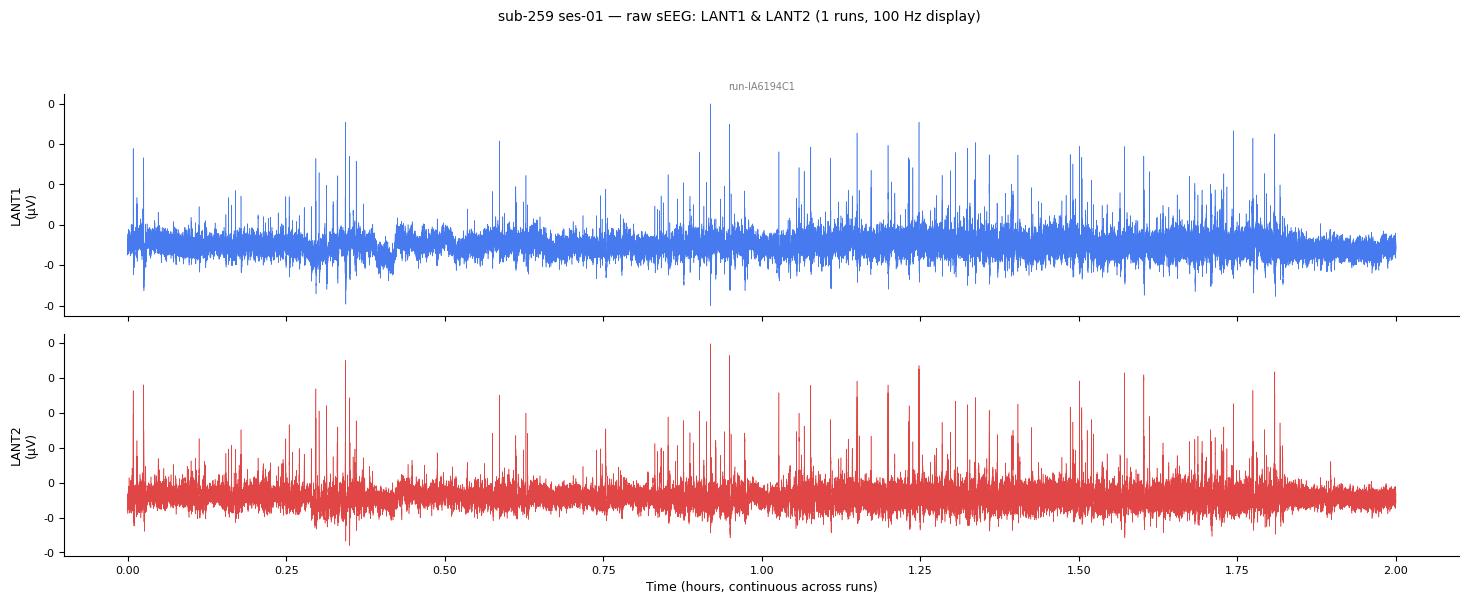

In [13]:
# ── Cell 4: plot (re-run freely without reloading data) ──────────────────────

fig, axes = plt.subplots(
    2, 1, figsize=(18, 6), sharex=True,
    gridspec_kw={"hspace": 0.08}
)
colors = ["#2563eb", "#dc2626"]

for t, data_ds in segments:
    for ch in range(2):
        axes[ch].plot(
            t / 3600, data_ds[:, ch],
            lw=0.4, color=colors[ch], alpha=0.85, rasterized=True
        )

# run boundary lines + labels
cum = 0.0
for i, (t, _) in enumerate(segments):
    if i > 0:
        for ax in axes:
            ax.axvline(cum / 3600, color="gray", lw=0.8, ls="--", alpha=0.6)
    mid = (cum + t[-1]) / 2 / 3600
    axes[0].text(
        mid, 1.01, f"run-{run_names[i]}",
        transform=axes[0].get_xaxis_transform(),
        ha="center", va="bottom", fontsize=7, color="gray"
    )
    cum += t[-1] + (1.0 / DOWNSAMPLE_HZ)

for ch, ax in enumerate(axes):
    ax.set_ylabel(f"{chan_labels[ch]}\n(μV)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (hours, continuous across runs)", fontsize=9)
fig.suptitle(
    f"{SUB} {SES} — raw sEEG: {chan_labels[0]} & {chan_labels[1]} "
    f"({len(segments)} runs, {DOWNSAMPLE_HZ} Hz display)",
    fontsize=10, y=1.02
)
plt.tight_layout()

# uncomment to save:
# fig.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
# print(f"Saved → {OUTPUT_PNG}")

plt.show()